In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [6]:
df = pd.read_csv('C:/Users/Anastasia_Golubova/Yandex.Disk/OTUS_Networks/hw_boosting/WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv')

In [8]:
df

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,LA72316,California,23405.987980,No,Basic,Bachelor,2/10/11,Employed,M,71941,...,89,0,2,Personal Auto,Personal L1,Offer2,Web,198.234764,Four-Door Car,Medsize
9130,PK87824,California,3096.511217,Yes,Extended,College,2/12/11,Employed,F,21604,...,28,0,1,Corporate Auto,Corporate L3,Offer1,Branch,379.200000,Four-Door Car,Medsize
9131,TD14365,California,8163.890428,No,Extended,Bachelor,2/6/11,Unemployed,M,0,...,37,3,2,Corporate Auto,Corporate L2,Offer1,Branch,790.784983,Four-Door Car,Medsize
9132,UP19263,California,7524.442436,No,Extended,College,2/3/11,Employed,M,21941,...,3,0,3,Personal Auto,Personal L2,Offer3,Branch,691.200000,Four-Door Car,Large


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

### EDA

In [13]:
### удалим ненужную колонку Customer
df = df.drop(columns='Customer')

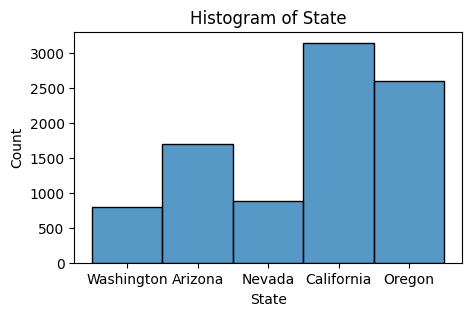

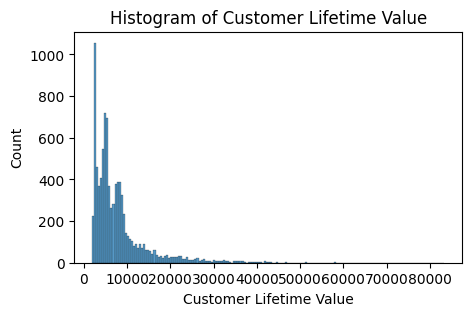

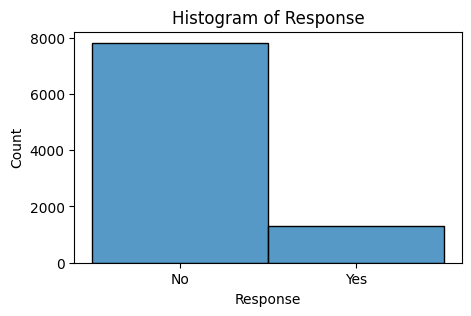

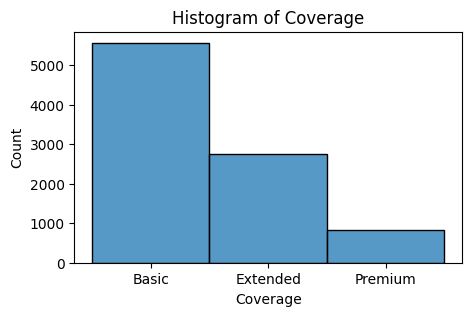

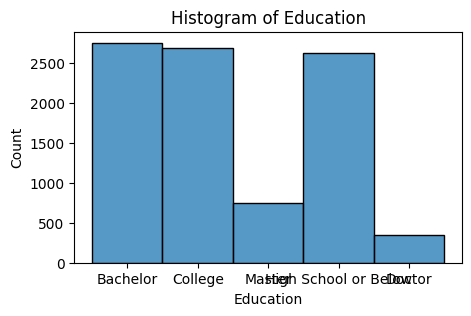

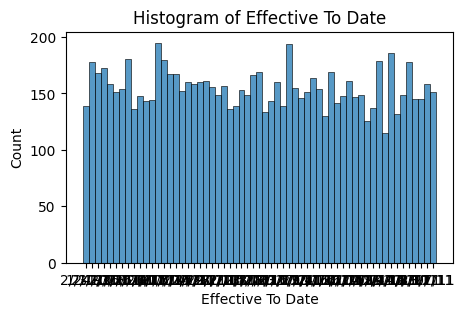

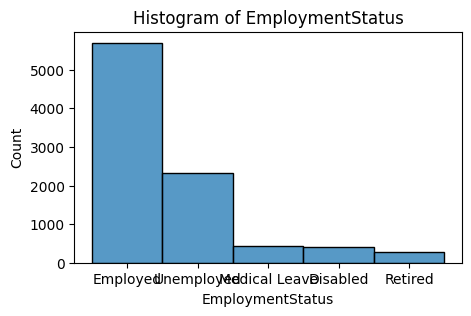

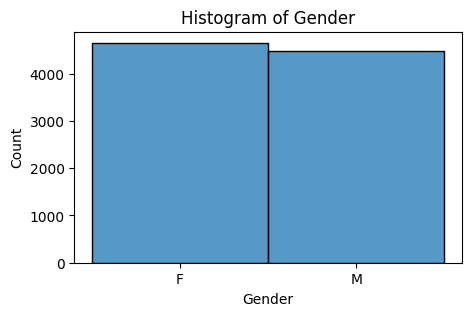

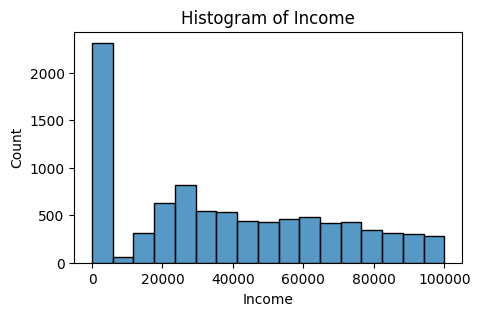

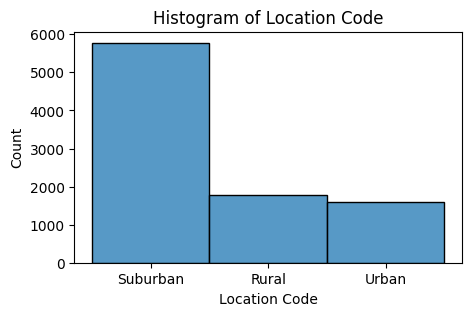

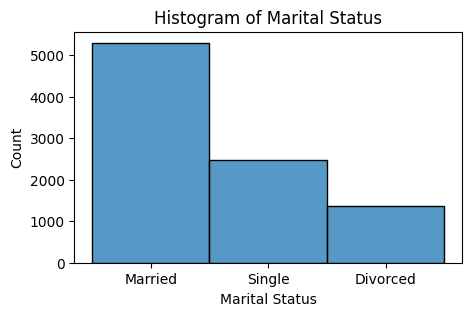

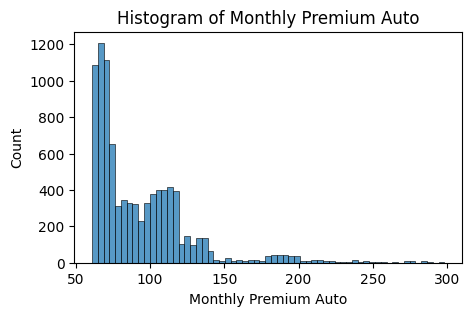

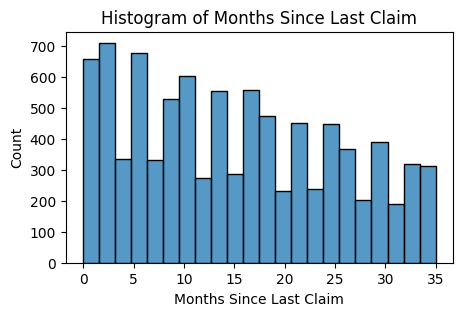

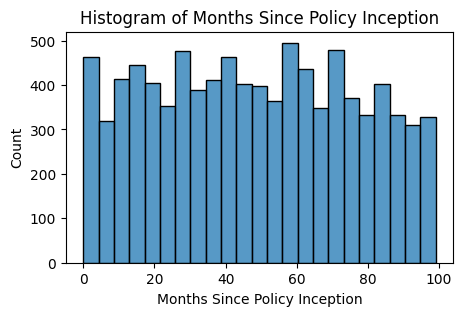

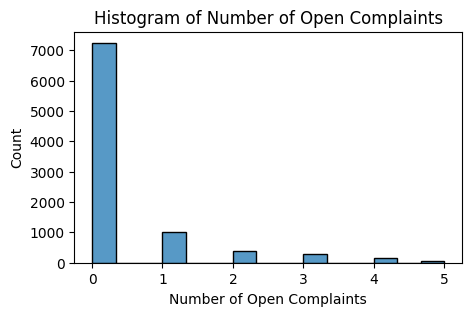

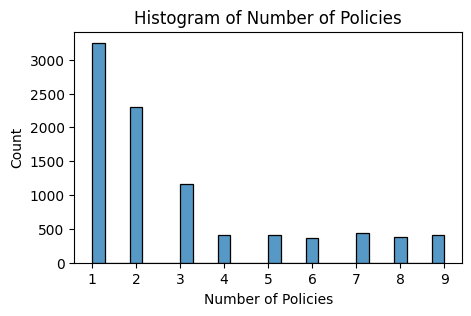

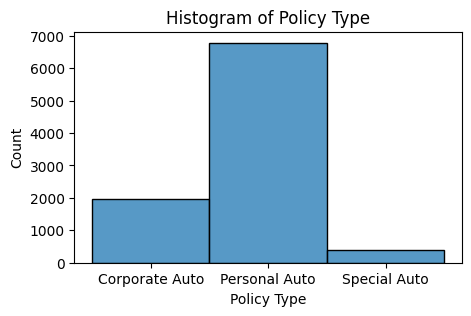

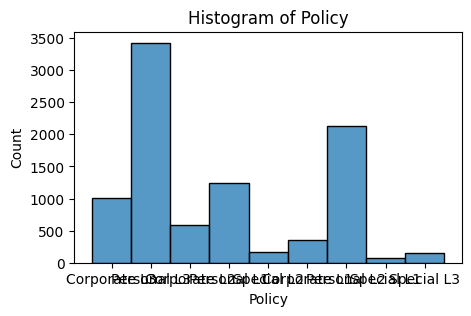

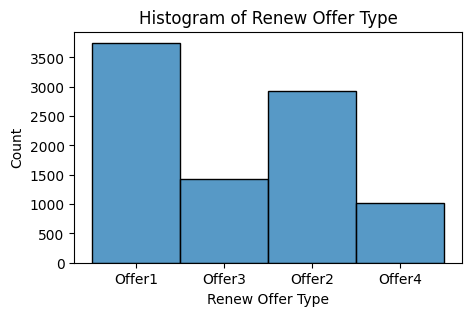

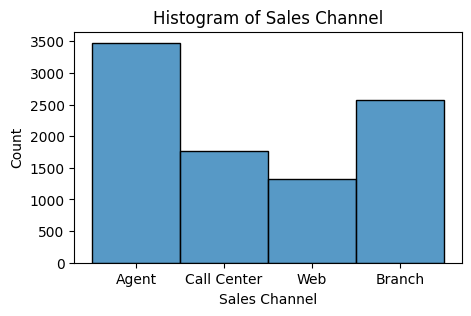

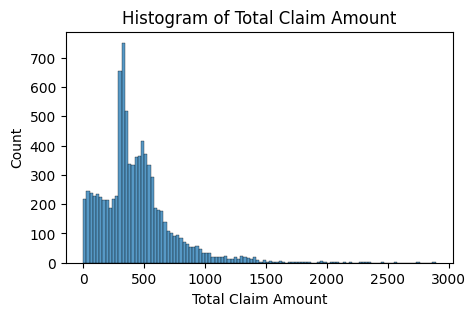

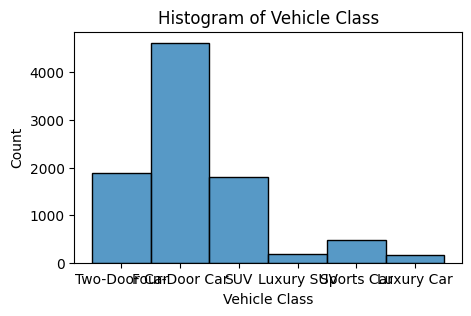

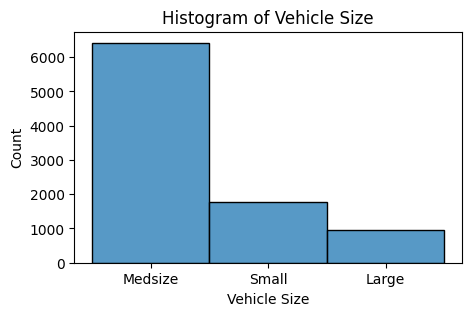

In [14]:
for col in df.columns:
    plt.figure(figsize=(5, 3))

    values = df[col]
    n_nan = values.isna().sum()

    sns.histplot(values.dropna())

    if n_nan > 0:
        plt.bar(["NaN"], [n_nan], color="red")

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [16]:
df = df.drop(columns='Effective To Date')

In [17]:
#check missing values
df.isnull().sum()

State                            0
Customer Lifetime Value          0
Response                         0
Coverage                         0
Education                        0
EmploymentStatus                 0
Gender                           0
Income                           0
Location Code                    0
Marital Status                   0
Monthly Premium Auto             0
Months Since Last Claim          0
Months Since Policy Inception    0
Number of Open Complaints        0
Number of Policies               0
Policy Type                      0
Policy                           0
Renew Offer Type                 0
Sales Channel                    0
Total Claim Amount               0
Vehicle Class                    0
Vehicle Size                     0
dtype: int64

In [18]:
numeric = df.select_dtypes(include='number')
numeric.describe()

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,37657.380009,93.219291,15.097000,48.064594,0.384388,2.966170,434.088794
std,6870.967608,30379.904734,34.407967,10.073257,27.905991,0.910384,2.390182,290.500092
min,1898.007675,0.000000,61.000000,0.000000,0.000000,0.000000,1.000000,0.099007
25%,3994.251794,0.000000,68.000000,6.000000,24.000000,0.000000,1.000000,272.258244
50%,5780.182197,33889.500000,83.000000,14.000000,48.000000,0.000000,2.000000,383.945434
75%,8962.167041,62320.000000,109.000000,23.000000,71.000000,0.000000,4.000000,547.514839
max,83325.381190,99981.000000,298.000000,35.000000,99.000000,5.000000,9.000000,2893.239678


In [30]:
### преобразуем категориальные признаки
## One hot encoding - State, Response, EmploymentStatus, Gender, Location Code, Marital Status, Policy Type, Policy, Renew Offer Type, Sales Channel, Vehicle Class
## Ordinal encoding - Coverage, Education, Vehicle Size

data_cat = df.select_dtypes(include='object')
data_cat_one = data_cat[['State', 'Response', 'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Policy',
                         'Renew Offer Type', 'Sales Channel', 'Vehicle Class']]
data_cat_one = pd.get_dummies(data_cat_one).astype(int)

enc1 = OrdinalEncoder(
    categories=[["Basic", "Extended", 'Premium']])
data_cat['Coverage_enc'] = enc1.fit_transform(data_cat[['Coverage']])

enc2 = OrdinalEncoder(
    categories=[["High School or Below", "College", 'Bachelor','Master','Doctor']])
data_cat['Education_enc'] = enc2.fit_transform(data_cat[['Education']])

enc3 = OrdinalEncoder(
    categories=[["Small", "Medsize", 'Large']])
data_cat['Vehicle Size_enc'] = enc3.fit_transform(data_cat[['Vehicle Size']])

data_cat_all = df.select_dtypes(include='object')
df_enc = df.drop(columns=data_cat_all.columns)
df_enc = pd.concat([df_enc,data_cat_one,data_cat['Coverage_enc'],data_cat['Education_enc'],data_cat['Vehicle Size_enc']],axis=1)

In [39]:
y = df_enc['Customer Lifetime Value']
X = df_enc.drop(columns='Customer Lifetime Value')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### предскажем Customer Lifetime Value

In [40]:
### gbr с параметрами из коробки

# gbr = GradientBoostingRegressor(random_state=42)
gbr = GradientBoostingRegressor(
    loss='squared_error',
    learning_rate=0.1,
    n_estimators=100,
    subsample=1.0,
    criterion='friedman_mse',
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_depth=3,
    min_impurity_decrease=0.0,
    init=None,
    random_state=42,
    max_features=None,
    alpha=0.9,
    verbose=0,
    max_leaf_nodes=None,
    warm_start=False,
    validation_fraction=0.1,
    n_iter_no_change=None,
    tol=1e-4,
    ccp_alpha=0.0
)

In [93]:
gbr.fit(X_train, y_train)

#TRAINING
y_pred1 = gbr.predict(X_train)
print("Train\nR²:", r2_score(y_train, y_pred1))
print("MAE:", mean_absolute_error(y_train, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred1)))

#TEST
y_pred = gbr.predict(X_test)
print("Test\nR²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train
R²: 0.7313873070998366
MAE: 1610.7788890171887
RMSE: 3560.720818141553
Test
R²: 0.7002673517585125
MAE: 1740.471607425866
RMSE: 3761.9428752141985


In [53]:
### XGBoost

# xgb = XGBRegressor(random_state=42)
xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    verbosity=1,
    booster='gbtree',
    tree_method='auto',
    n_jobs=None,
    gamma=0,
    min_child_weight=1,
    max_delta_step=0,
    subsample=1,
    colsample_bytree=1,
    colsample_bylevel=1,
    colsample_bynode=1,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    base_score=0.5,
    random_state=42
)

In [92]:
xgb.fit(X_train, y_train)

#TRAINING
y_pred1 = xgb.predict(X_train)
print("Train\nR²:", r2_score(y_train, y_pred1))
print("MAE:", mean_absolute_error(y_train, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred1)))

#TEST
y_pred = xgb.predict(X_test)
print("Test\nR²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train
R²: 0.9529227674904854
MAE: 806.1906767437175
RMSE: 1490.6652263695985
Test
R²: 0.6796741092713683
MAE: 1944.8705531098249
RMSE: 3889.029095869476


In [55]:
### LightGBM

# lgbm = LGBMRegressor(random_state=42)
lgbm = LGBMRegressor(
    boosting_type='gbdt',
    objective='regression',
    num_leaves=31,
    max_depth=-1,
    learning_rate=0.1,
    n_estimators=100,
    subsample_for_bin=200000,
    min_split_gain=0.0,
    min_child_weight=1e-3,
    min_child_samples=20,
    subsample=1.0,
    subsample_freq=0,
    colsample_bytree=1.0,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=None
)

In [90]:
lgbm.fit(X_train, y_train)

#TRAINING
y_pred1 = lgbm.predict(X_train)
print("Train\nR²:", r2_score(y_train, y_pred1))
print("MAE:", mean_absolute_error(y_train, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred1)))

#TEST
y_pred = lgbm.predict(X_test)
print("Test\nR²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train
R²: 0.8777441317346123
MAE: 1100.6760718259322
RMSE: 2402.2019519107585
Test
R²: 0.7086160848649745
MAE: 1643.689319396993
RMSE: 3709.180417577201


In [57]:
### catboost

cat = CatBoostRegressor(
    loss_function='RMSE',
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    random_seed=42,
    verbose=0
)

In [89]:
cat.fit(X_train, y_train)

#TRAINING
y_pred1 = cat.predict(X_train)
print("Train\nR²:", r2_score(y_train, y_pred1))
print("MAE:", mean_absolute_error(y_train, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred1)))

#TEST
y_pred = cat.predict(X_test)
print("Test\nR²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train
R²: 0.8250949377203072
MAE: 1378.2555744964332
RMSE: 2873.2660944526574
Test
R²: 0.7157276022020426
MAE: 1726.6318538434448
RMSE: 3663.637683827945


### модели дают схожие результаты, XGBboost судя по разнице между метриками на трейне и тесте, переобучается на данных. С незначительным отрывом метрики оказались в целом лучше для  LightGBM

#### сделаем подбор гиперпараметров

In [83]:
### gbr

from sklearn.model_selection import GridSearchCV, KFold

def tune_gbr(X_train, y_train):

    param_grid = {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_features": ["sqrt", "log2", None]
    }

    model = GradientBoostingRegressor(random_state=42)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    grid = GridSearchCV(
        model,
        param_grid,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print("Best score:", grid.best_score_)
    print("Best params:", grid.best_params_)

    return grid.best_estimator_

In [84]:
best_gbr = tune_gbr(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best score: -3921.407390340719
Best params: {'learning_rate': 0.1, 'max_features': None, 'n_estimators': 100}


In [88]:
#TRAINING
y_pred1 = best_gbr.predict(X_train)
print("Train\nR²:", r2_score(y_train, y_pred1))
print("MAE:", mean_absolute_error(y_train, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred1)))

#TEST
y_pred = best_gbr.predict(X_test)
print("Test\nR²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train
R²: 0.7313873070998366
MAE: 1610.7788890171887
RMSE: 3560.720818141553
Test
R²: 0.7002673517585125
MAE: 1740.471607425866
RMSE: 3761.9428752141985


In [80]:
### XGBoost

def tune_xgb(X_train, y_train):

    param_grid = {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1],
        "colsample_bytree": [0.5, 0.8, 1.0]
    }

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        verbosity=0
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    grid = GridSearchCV(
        model,
        param_grid,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print("Best score:", grid.best_score_)
    print("Best params:", grid.best_params_)

    return grid.best_estimator_

In [81]:
best_xgb = tune_xgb(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best score: -3857.207998116001
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'n_estimators': 500}


In [87]:
#TRAINING
y_pred1 = best_xgb.predict(X_train)
print("Train\nR²:", r2_score(y_train, y_pred1))
print("MAE:", mean_absolute_error(y_train, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred1)))

#TEST
y_pred = best_xgb.predict(X_test)
print("Test\nR²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train
R²: 0.8088812023933285
MAE: 1304.2090698416628
RMSE: 3003.4911773607364
Test
R²: 0.7112885863657857
MAE: 1623.9450809591117
RMSE: 3692.1313905548172


In [77]:
### LightGBM

def tune_lgbm(X_train, y_train):

    param_grid = {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1],
        "colsample_bytree": [0.5, 0.8, 1.0]
    }

    model = LGBMRegressor(
        objective="regression",
        random_state=42,
        verbose=-1
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    grid = GridSearchCV(
        model,
        param_grid,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print("Best score:", grid.best_score_)
    print("Best params:", grid.best_params_)

    return grid.best_estimator_

In [78]:
best_lgbm = tune_lgbm(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best score: -3832.6982426573995
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'n_estimators': 500}


In [86]:
#TRAINING
y_pred1 = best_lgbm.predict(X_train)
print("Train\nR²:", r2_score(y_train, y_pred1))
print("MAE:", mean_absolute_error(y_train, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred1)))

#TEST
y_pred = best_lgbm.predict(X_test)
print("Test\nR²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train
R²: 0.8331736464733588
MAE: 1253.609367902127
RMSE: 2806.1248316893657
Test
R²: 0.7175055772557428
MAE: 1641.0280274937652
RMSE: 3652.162645052923


In [73]:
### CatBoost

def tune_catboost(X_train, y_train):

    param_grid = {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1],
        "rsm": [0.5, 0.8, 1.0]
    }

    model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    grid = GridSearchCV(
        model,
        param_grid,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print("Best score:", grid.best_score_)
    print("Best params:", grid.best_params_)

    return grid.best_estimator_

In [74]:
best_cat = tune_catboost(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best score: -3802.505230654146
Best params: {'learning_rate': 0.05, 'n_estimators': 500, 'rsm': 0.5}


In [85]:
#TRAINING
y_pred1 = best_cat.predict(X_train)
print("Train\nR²:", r2_score(y_train, y_pred1))
print("MAE:", mean_absolute_error(y_train, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred1)))

#TEST
y_pred = best_cat.predict(X_test)
print("Test\nR²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train
R²: 0.8120935068371281
MAE: 1419.9428251475858
RMSE: 2978.143033476567
Test
R²: 0.7136089937646354
MAE: 1748.8239229756484
RMSE: 3677.2644124735634


### Настройка гиперпараметров не помогла значительно улучшить метрики моделей. Наилушчими оказываются LightGBM и CatBoost